In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
yt = pd.read_csv("Global YouTube Statistics.csv", encoding="latin1")
import pickle
import pickle

with open("youtube_dataset.pkl", "rb") as file:
    yt = pickle.load(file)



In [3]:
yt.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [4]:
yt.isnull().sum()

rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month                                5
created_date 

In [5]:
yt.nunique()

rank                                       995
Youtuber                                   995
subscribers                                289
video views                                988
category                                    18
Title                                      992
uploads                                    777
Country                                     49
Abbreviation                                49
channel_type                                14
video_views_rank                           953
country_rank                               246
channel_type_rank                          286
video_views_for_the_last_30_days           908
lowest_monthly_earnings                    557
highest_monthly_earnings                   736
lowest_yearly_earnings                     757
highest_yearly_earnings                    419
subscribers_for_last_30_days                53
created_year                                19
created_month                               12
created_date 

In [6]:
yt.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
990    False
991    False
992    False
993    False
994    False
Length: 995, dtype: bool

In [7]:
yt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_rank                         994 non-n

In [8]:
yt.describe()

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,995.00000,9.950000e+02,9.950000e+02,995.000000,9.940000e+02,879.000000,962.000000,9.390000e+02,995.000000,9.950000e+02,...,9.950000e+02,6.580000e+02,990.000000,990.000000,872.000000,8.720000e+02,872.000000,8.720000e+02,872.000000,872.000000
mean,498.00000,2.298241e+07,1.103954e+10,9187.125628,5.542489e+05,386.053470,745.719335,1.756103e+08,36886.148281,5.898078e+05,...,7.081814e+06,3.490791e+05,2012.630303,15.746465,63.627752,4.303873e+08,9.279278,2.242150e+08,26.632783,-14.128146
std,287.37606,1.752611e+07,1.411084e+10,34151.352254,1.362782e+06,1232.244746,1944.386561,4.163782e+08,71858.724092,1.148622e+06,...,1.379704e+07,6.143554e+05,4.512503,8.777520,26.106893,4.727947e+08,4.888354,1.546874e+08,20.560533,84.760809
min,1.00000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,1.000000e+00,1970.000000,1.000000,7.600000,2.025060e+05,0.750000,3.558800e+04,-38.416097,-172.104629
25%,249.50000,1.450000e+07,4.288145e+09,194.500000,3.230000e+02,11.000000,27.000000,2.013750e+07,2700.000000,4.350000e+04,...,5.217500e+05,1.000000e+05,2009.000000,8.000000,36.300000,8.335541e+07,5.270000,5.590832e+07,20.593684,-95.712891
50%,498.00000,1.770000e+07,7.760820e+09,729.000000,9.155000e+02,51.000000,65.500000,6.408500e+07,13300.000000,2.127000e+05,...,2.600000e+06,2.000000e+05,2013.000000,16.000000,68.000000,3.282395e+08,9.365000,2.706630e+08,37.090240,-51.925280
75%,746.50000,2.460000e+07,1.355470e+10,2667.500000,3.584500e+03,123.000000,139.750000,1.688265e+08,37900.000000,6.068000e+05,...,7.300000e+06,4.000000e+05,2016.000000,23.000000,88.200000,3.282395e+08,14.700000,2.706630e+08,37.090240,78.962880
max,995.00000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06,7741.000000,7741.000000,6.589000e+09,850900.000000,1.360000e+07,...,1.634000e+08,8.000000e+06,2022.000000,31.000000,113.100000,1.397715e+09,14.720000,8.429340e+08,61.924110,138.252924


In [9]:
pd.set_option("display.float_format", "{:.0f}".format)

In [10]:
category_wise_subscribers=yt.groupby("category")["subscribers"].mean()

In [11]:
category_wise_subscribers.sort_values(ascending=False)

category
Shows                   41615385
Trailers                39000000
Film & Animation        28584783
Nonprofits & Activism   27750000
Sports                  27109091
Education               26542222
Music                   25717822
Movies                  25650000
Entertainment           21403320
People & Blogs          21056061
Gaming                  20852128
News & Politics         20630769
Comedy                  20123188
Howto & Style           19390000
Science & Technology    18617647
Pets & Animals          18100000
Autos & Vehicles        17850000
Travel & Events         12500000
Name: subscribers, dtype: float64

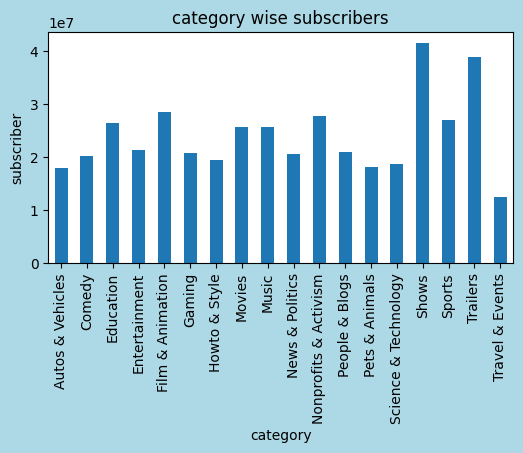

In [12]:
plt.figure(figsize=(6,3),facecolor="lightblue")
category_wise_subscribers.plot(kind = "bar") # i can get top 5 records by category_wise_subscribers.head().plot
plt.title("category wise subscribers")
plt.xlabel("category")
plt.ylabel("subscriber")
plt.xticks(rotation = 90)
plt.show()

In [13]:
chanel_counts=yt["channel_type"].value_counts()

In [14]:
chanel_counts

channel_type
Entertainment    304
Music            216
People           101
Games             98
Comedy            51
Education         49
Film              42
Howto             36
News              30
Tech              17
Sports            13
Autos              3
Animals            3
Nonprofit          2
Name: count, dtype: int64

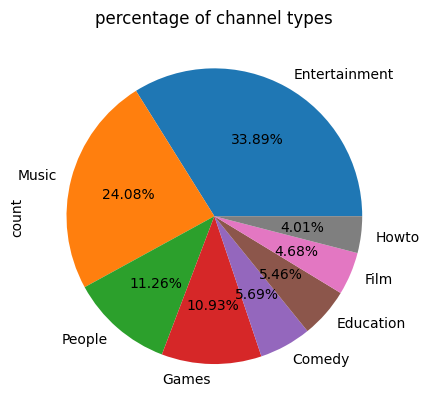

In [15]:
chanel_counts.head(8).plot(kind = "pie",autopct="%1.2f%%")
plt.title("percentage of channel types")
plt.show()

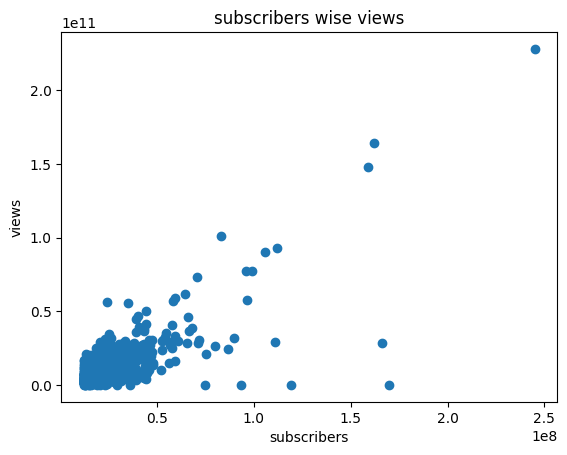

In [16]:
plt.scatter(yt["subscribers"],yt["video views"])
plt.title("subscribers wise views")
plt.xlabel("subscribers")
plt.ylabel("views")
plt.show()

In [17]:
yt.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title',
       'uploads', 'Country', 'Abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude'],
      dtype='object')

In [18]:
country_wise_subscribers=yt.groupby("Country")["subscribers"].sum().sort_values(ascending=False)

In [19]:
country_wise_subscribers.head()

Country
United States     7329500000
India             4310600000
Brazil            1221800000
United Kingdom     917400000
Mexico             626900000
Name: subscribers, dtype: int64

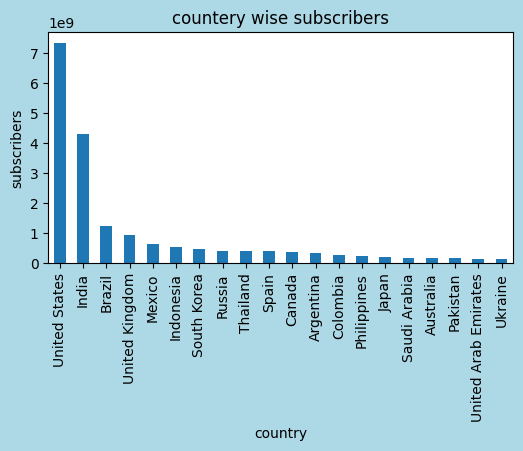

In [20]:
plt.figure(figsize=(6,3),facecolor="lightblue")
country_wise_subscribers.head(20).plot(kind="bar")
plt.title("countery wise subscribers")
plt.xlabel("country")
plt.ylabel("subscribers")
plt.show()

In [21]:
yt.groupby("created_year")["subscribers"].mean().sort_values(ascending=False)

created_year
1970   36300000
2006   31884615
2005   25829167
2007   24902041
2013   24527632
2012   24038235
2008   23652174
2009   23105769
2016   23101299
2018   23060870
2011   21800000
2020   21350000
2015   21247945
2010   20670833
2014   20618367
2017   18666176
2019   18639394
2021   18573913
2022   13640000
Name: subscribers, dtype: float64

In [22]:
yt.groupby("channel_type")["video_views_rank"].median().sort_values(ascending=False)

channel_type
Autos           3468229
Tech               2420
Games              1944
People             1868
Howto              1574
Nonprofit          1538
Sports             1186
Comedy             1033
Film                880
Entertainment       796
News                612
Education           538
Music               385
Animals             136
Name: video_views_rank, dtype: float64

In [23]:
yt.groupby("Country")["subscribers_for_last_30_days"].max().sort_values(ascending=False).head()

Country
United States          8000000
Indonesia              5500000
United Arab Emirates   3400000
South Korea            3200000
Sweden                 3000000
Name: subscribers_for_last_30_days, dtype: float64

In [24]:
yt.groupby("category")["video views"].sum()

category
Autos & Vehicles          15003458141
Comedy                   550112774315
Education                696614472899
Entertainment           2527739309583
Film & Animation         544422509313
Gaming                   717638899629
Howto & Style            201817545540
Movies                    15383255129
Music                   3121477506633
News & Politics          270391919347
Nonprofits & Activism     10862911785
People & Blogs          1265791201548
Pets & Animals            44866745899
Science & Technology      66976747110
Shows                    446206826909
Sports                   147986290620
Trailers                  33262717607
Travel & Events            3140883140
Name: video views, dtype: float64

In [25]:
yt.groupby("Country")["Unemployment rate"].min().sort_values(ascending=False).head()

Country
Jordan          15
United States   15
Spain           14
Turkey          13
Iraq            13
Name: Unemployment rate, dtype: float64

In [26]:
yt.groupby("channel_type")["uploads"].sum()

channel_type
Animals            42868
Autos                949
Comedy             81722
Education         146355
Entertainment    3345035
Film              114654
Games             399473
Howto              79417
Music             424950
News             3989151
Nonprofit         205824
People            117424
Sports            158995
Tech               33780
Name: uploads, dtype: int64

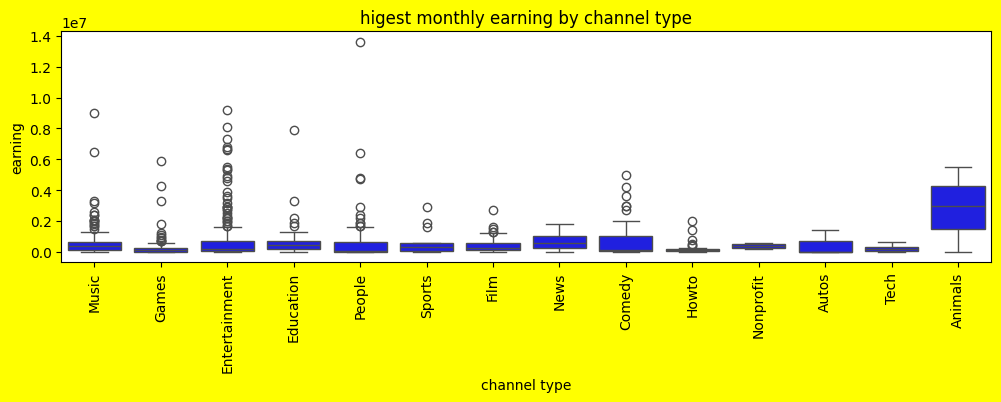

In [27]:
plt.figure(figsize=(12,3),facecolor="yellow")
sns.boxplot(x="channel_type", y="highest_monthly_earnings", data=yt,color="blue")
plt.title("higest monthly earning by channel type")
plt.xlabel("channel type")
plt.ylabel("earning")
plt.xticks(rotation=90)
plt.show()

In [28]:
yt.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title',
       'uploads', 'Country', 'Abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

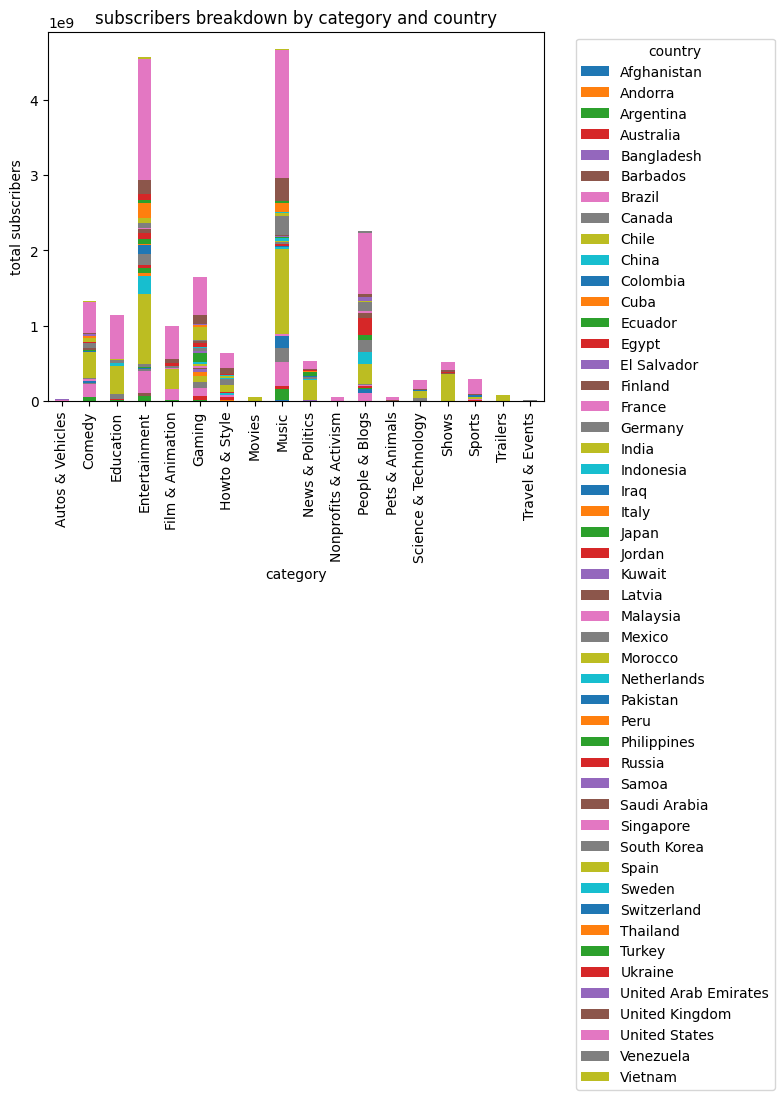

In [29]:
plt.figure(facecolor="yellow")
yt.groupby(["category","Country"])["subscribers"].sum().unstack().plot(kind="bar",stacked=True)
plt.title("subscribers breakdown by category and country")
plt.xlabel("category")
plt.ylabel("total subscribers")
plt.legend(title = "country", bbox_to_anchor = (1.05,1), loc = "upper left")
plt.show()

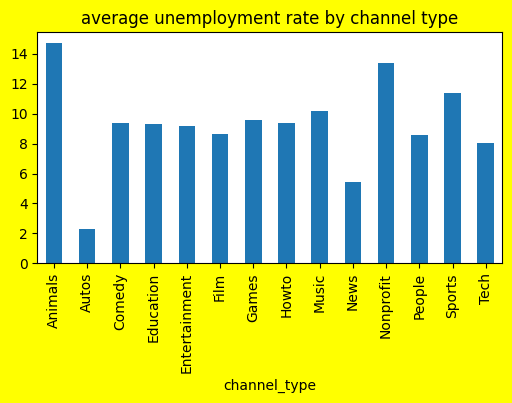

In [30]:
plt.figure(figsize=(6,3),facecolor="yellow")
yt.groupby("channel_type")["Unemployment rate"].mean().plot(kind="bar")
plt.title("average unemployment rate by channel type")
plt.show()

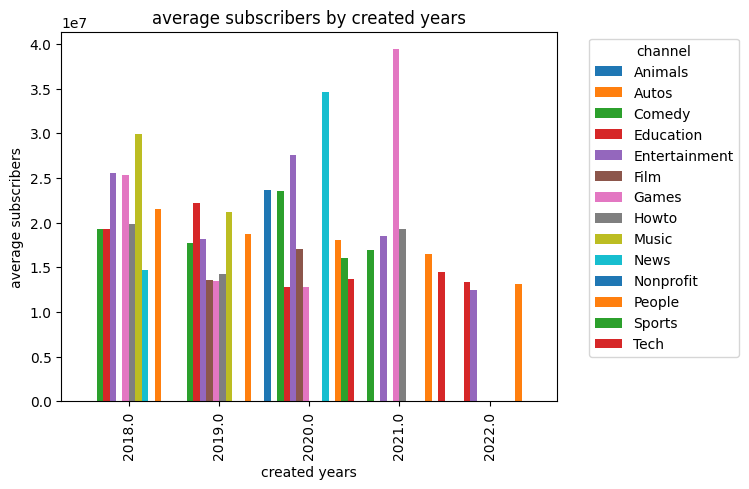

In [31]:
yt.groupby(["created_year","channel_type"])["subscribers"].mean().unstack().tail().plot(kind="bar", width=1)
plt.title("average subscribers by created years")
plt.xlabel("created years")
plt.ylabel("average subscribers")
plt.legend(title="channel", bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

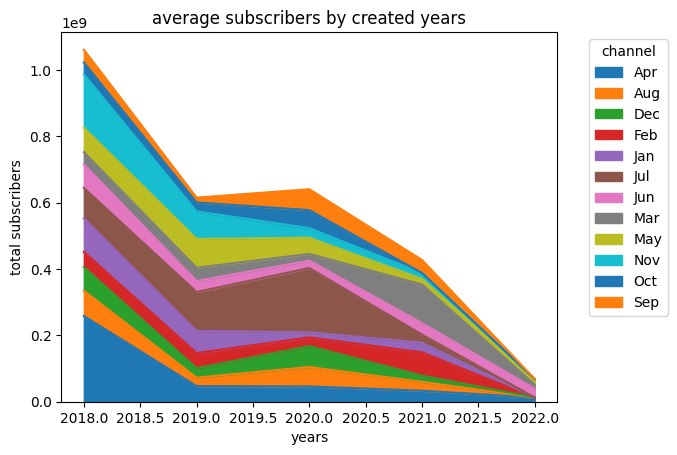

In [32]:
yt.groupby(["created_year","created_month"])["subscribers"].sum().unstack().tail().plot(kind="area", stacked=True)
plt.title("average subscribers by created years")
plt.xlabel("years")
plt.ylabel("total subscribers")
plt.legend(title="channel", bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

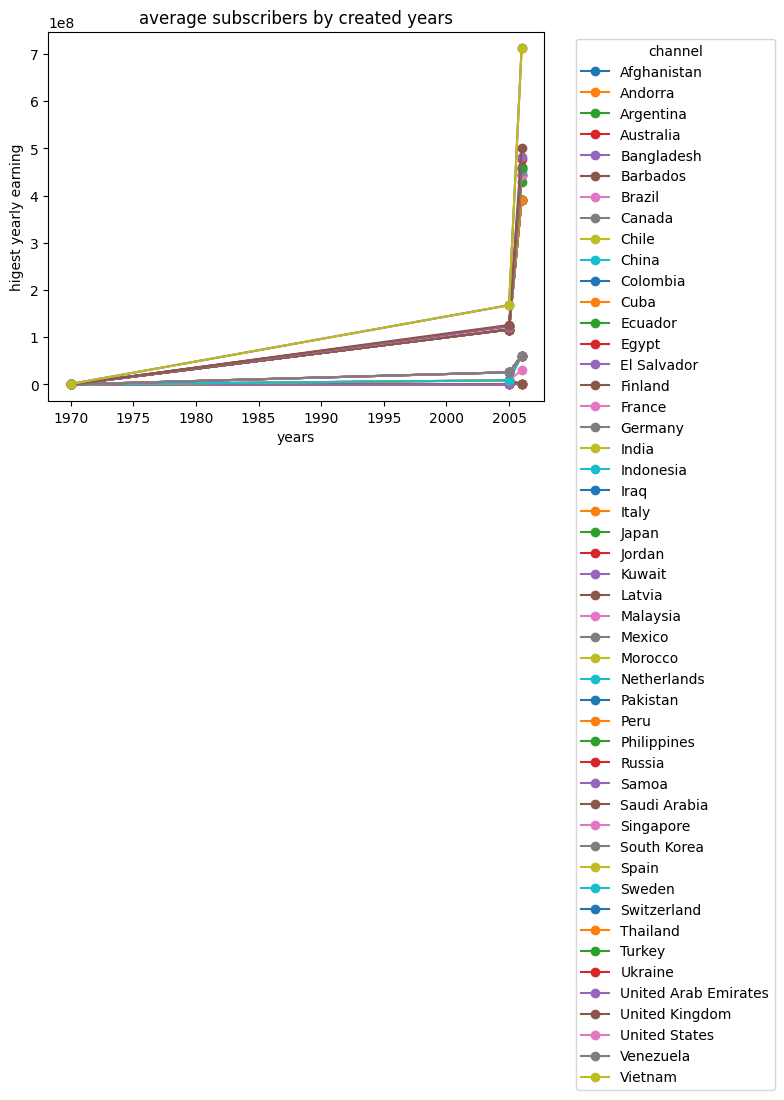

In [33]:
yt.groupby(["created_year","Country"])["highest_yearly_earnings"].sum().unstack().head(3).plot(kind="line", stacked=True,marker="o")
plt.title("average subscribers by created years")
plt.xlabel("years")
plt.ylabel("higest yearly earning")
plt.legend(title="channel", bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

In [34]:
yt.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title',
       'uploads', 'Country', 'Abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude'],
      dtype='object')

In [35]:
category_wise_higest_earning=yt.groupby("category")["highest_monthly_earnings"].sum()

In [36]:
category_wise_higest_earning

category
Autos & Vehicles          2172700
Comedy                   46113543
Education                31283000
Entertainment           150056865
Film & Animation         33704283
Gaming                   25559111
Howto & Style             7711962
Movies                     909400
Music                   111564524
News & Politics          16708431
Nonprofits & Activism      780800
People & Blogs           72183154
Pets & Animals            3177729
Science & Technology      3434735
Shows                    26489600
Sports                    8876300
Trailers                   723800
Travel & Events            124000
Name: highest_monthly_earnings, dtype: float64

Text(0.5, 1.0, 'category wise highest monthly earning')

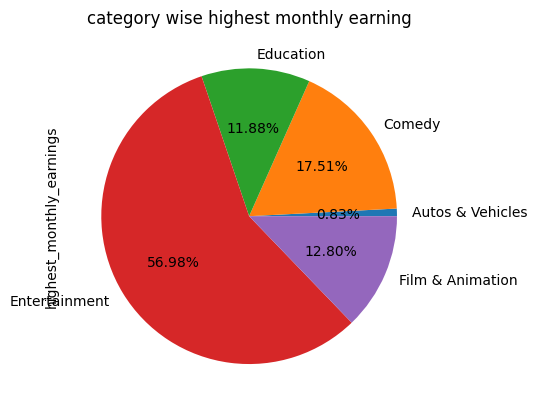

In [37]:
yt.groupby("category")["highest_monthly_earnings"].sum().head().plot(kind="pie",autopct="%1.2f%%")
plt.title("category wise highest monthly earning")

In [38]:
channel_created_subscribers=yt.groupby(["channel_type","created_year"])["subscribers_for_last_30_days"].mean().unstack()

In [39]:
channel_created_subscribers

created_year,1970,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
channel_type,,,,,,,,,,,,,,,,,,,
Animals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,600000,NaN,NaN,NaN,NaN,NaN,1100000,NaN,NaN
Autos,NaN,NaN,2,500000,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Comedy,NaN,400000,100000,100000,200000,400000,NaN,50000,NaN,100000,1166667,150000,700000,100000,200050,1000000,1200000,600000,NaN
Education,NaN,NaN,700000,NaN,200000,100000,200000,200000,350000,283333,550000,200000,233333,200000,200000,100000,300000,NaN,300000
Entertainment,300000,325000,306250,342857,450000,480000,212575,442857,760000,233334,200000,300000,830001,700000,230769,160000,1212500,580000,500000
Film,NaN,1,333333,NaN,100000,NaN,NaN,225008,300000,350000,342857,250000,250000,600000,NaN,500000,450500,NaN,NaN
Games,NaN,100000,338,50006,100000,200000,3,150000,376923,245455,260000,660716,357143,100003,151000,NaN,750000,NaN,NaN
Howto,NaN,500000,NaN,NaN,NaN,100000,100000,NaN,NaN,NaN,NaN,100000,100000,100000,633333,100000,NaN,300000,NaN
Music,NaN,160000,433334,146160,185385,153846,175000,158829,200000,400000,230769,125016,240010,300000,300000,50005,NaN,NaN,NaN


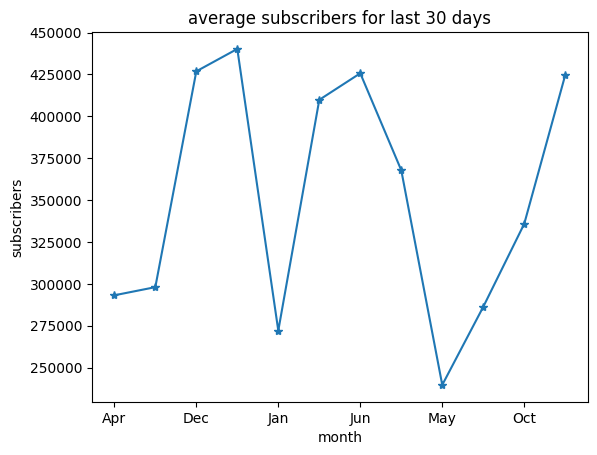

In [40]:
yt.groupby("created_month")["subscribers_for_last_30_days"].mean().plot(kind="line",marker="*")
plt.title("average subscribers for last 30 days")
plt.xlabel("month")
plt.ylabel("subscribers")
plt.show()

In [48]:
import streamlit as st
import pickle
import pandas as pd

st.title("📊 YouTube Dataset Viewer")

# Load PKL file
with open("youtube_dataset.pkl", "rb") as file:
    yt = pickle.load(file)

st.subheader("Dataset Preview")
st.dataframe(yt.head(50))   # show first 50 rows

st.subheader("Dataset Info")
st.write("Shape:", yt.shape)

st.subheader("Column Names")
st.write(list(yt.columns))


2025-12-27 14:48:58.429 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-27 14:48:58.429 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-27 14:48:58.429 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-27 14:48:58.437 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-27 14:48:58.437 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-27 14:48:58.437 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-27 14:48:58.445 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-27 14:48:58.453 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [44]:
pip install streamlit 

  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached protobuf-6.33.2-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached gitpython-3.1.45-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.2-py3-none-any.whl.metadata (4.3 kB)
   ---------------------------------------- 0.0/9.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.0 MB 445.2 kB/s eta 0:00:21
   ---------------------------------------